Exemple simple
Supposons un robot dans une grille 2x2 :
États	Actions possibles
(0,0)	Haut, Bas, Gauche, Droite
(0,1)	Haut, Bas, Gauche, Droite
...	...
•	Récompense : +1 si le robot atteint (1,1), 0 sinon.
•	Facteur de discount : (\gamma = 0.9)
Le robot utilisera Value Iteration pour calculer (V(s)) et déterminer la politique optimale pour atteindre (1,1) avec le maximum de récompense attendue.


In [16]:
import numpy as np

In [17]:
# Définition du MDP
states = [(0,0), (0,1), (1,0), (1,1)]  # États de la grille
actions = ['up', 'down', 'left', 'right']  # Actions possibles
gamma = 0.9  # Facteur de discount ( facteur d'actualisation)
theta = 1e-4  # Critère de convergence

# Fonction de transition (transition_reward) et récompense : Cette fonction définit :
#la dynamique de l’environnement la récompense
def transition_reward(s, a):   # s c'est l'etat de l'agent. -s = (ligne, colonne)
    x, y = s   # Prendre les deux valeurs contenues dans s et les stocker séparément dans x et y.
    if s == (1,1):
        return s, 0  # état terminal
    if a == 'up': # empêche de sortir de la grille. par exemple depuis (0,0), aller en haut garde l’agent à (0,0)
        next_state = (max(x-1,0), y) # On utilise max et min pour empêcher l’agent de sortir de la grille. max(x-1,0) empêche les indices négatifs.
    elif a == 'down':
        next_state = (min(x+1,1), y)
    elif a == 'left':
        next_state = (x, max(y-1,0))
    elif a == 'right':
        next_state = (x, min(y+1,1))
    reward = 1 if next_state == (1,1) else 0 # (atteindre le but → récompense = 1 sinon → 0)
    return next_state, reward

# Initialisation de la valeur des états
#On initialise : 𝑉 (𝑠)=0 ∀ 𝑠 V(s)=0∀s . La fonction V(s) représente : la récompense future attendue en partant de l’état s
V = {s:0 for s in states}





In [18]:
# Value Iteration
def value_iteration():
    while True:
        delta = 0
        for s in states:
            v = V[s]
            V[s] = max(sum([transition_reward(s,a)[1] + gamma * V[transition_reward(s,a)[0]] for a in actions])/1 for a in actions)
            delta = max(delta, abs(v - V[s]))
        if delta < theta:
            break

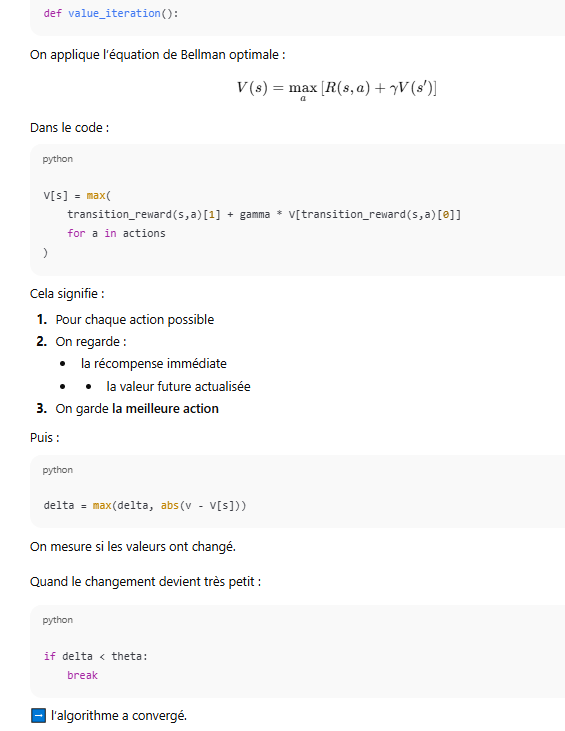

In [19]:
# Calculer la politique optimale
#Cette fonction permet de déduire la politique optimale
#à partir de la fonction de valeur optimale V(s) que tu #as déjà calculée (avec Value Iteration par exemple).
def extract_policy(): # On crée une fonction qui va retourner la politique optimale.
    policy = {} # Créer un dictionnaire vide  [clé  →  valeur]
    for s in states:
        if s == (1,1):
            policy[s] = None
        else:
            action_values = {}
            for a in actions:
                next_s, r = transition_reward(s,a)
                action_values[a] = r + gamma * V[next_s]
            policy[s] = max(action_values, key=action_values.get)
    return policy

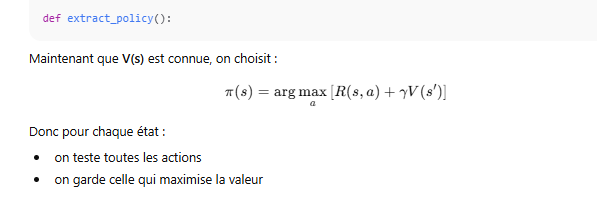

In [20]:


# Exécution
value_iteration()
optimal_policy = extract_policy()

print("Valeur des états :")
for s in states:
    print(f"{s}: {V[s]:.2f}")

print("\nPolitique optimale :")
for s in states:
    print(f"{s}: {optimal_policy[s]}")

Valeur des états :
(0, 0): inf
(0, 1): inf
(1, 0): inf
(1, 1): 0.00

Politique optimale :
(0, 0): up
(0, 1): up
(1, 0): up
(1, 1): None


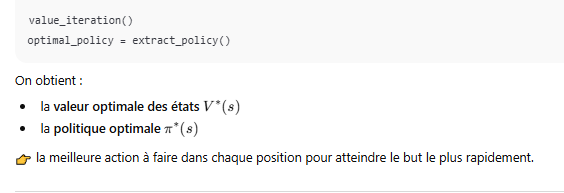

### Explications

transition_reward(s, a) : définit la transition d’état et la récompense.

V : dictionnaire stockant la valeur de chaque état.

Value Iteration met à jour les valeurs des états jusqu’à convergence.

extract_policy() : calcule la meilleure action à prendre dans chaque état selon les valeurs calculées.

L’état (1,1) est l’état terminal avec récompense +1